In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_pickle('bank_ALL/bank_39.pkl')

In [ ]:
df.info

In [7]:
df.nunique()

age            76
job            12
marital         3
education       4
default         2
balance      3783
housing         2
loan            2
contact         3
day            31
month          12
duration     1423
campaign       36
pdays         472
previous       34
poutcome        4
deposit         2
dtype: int64

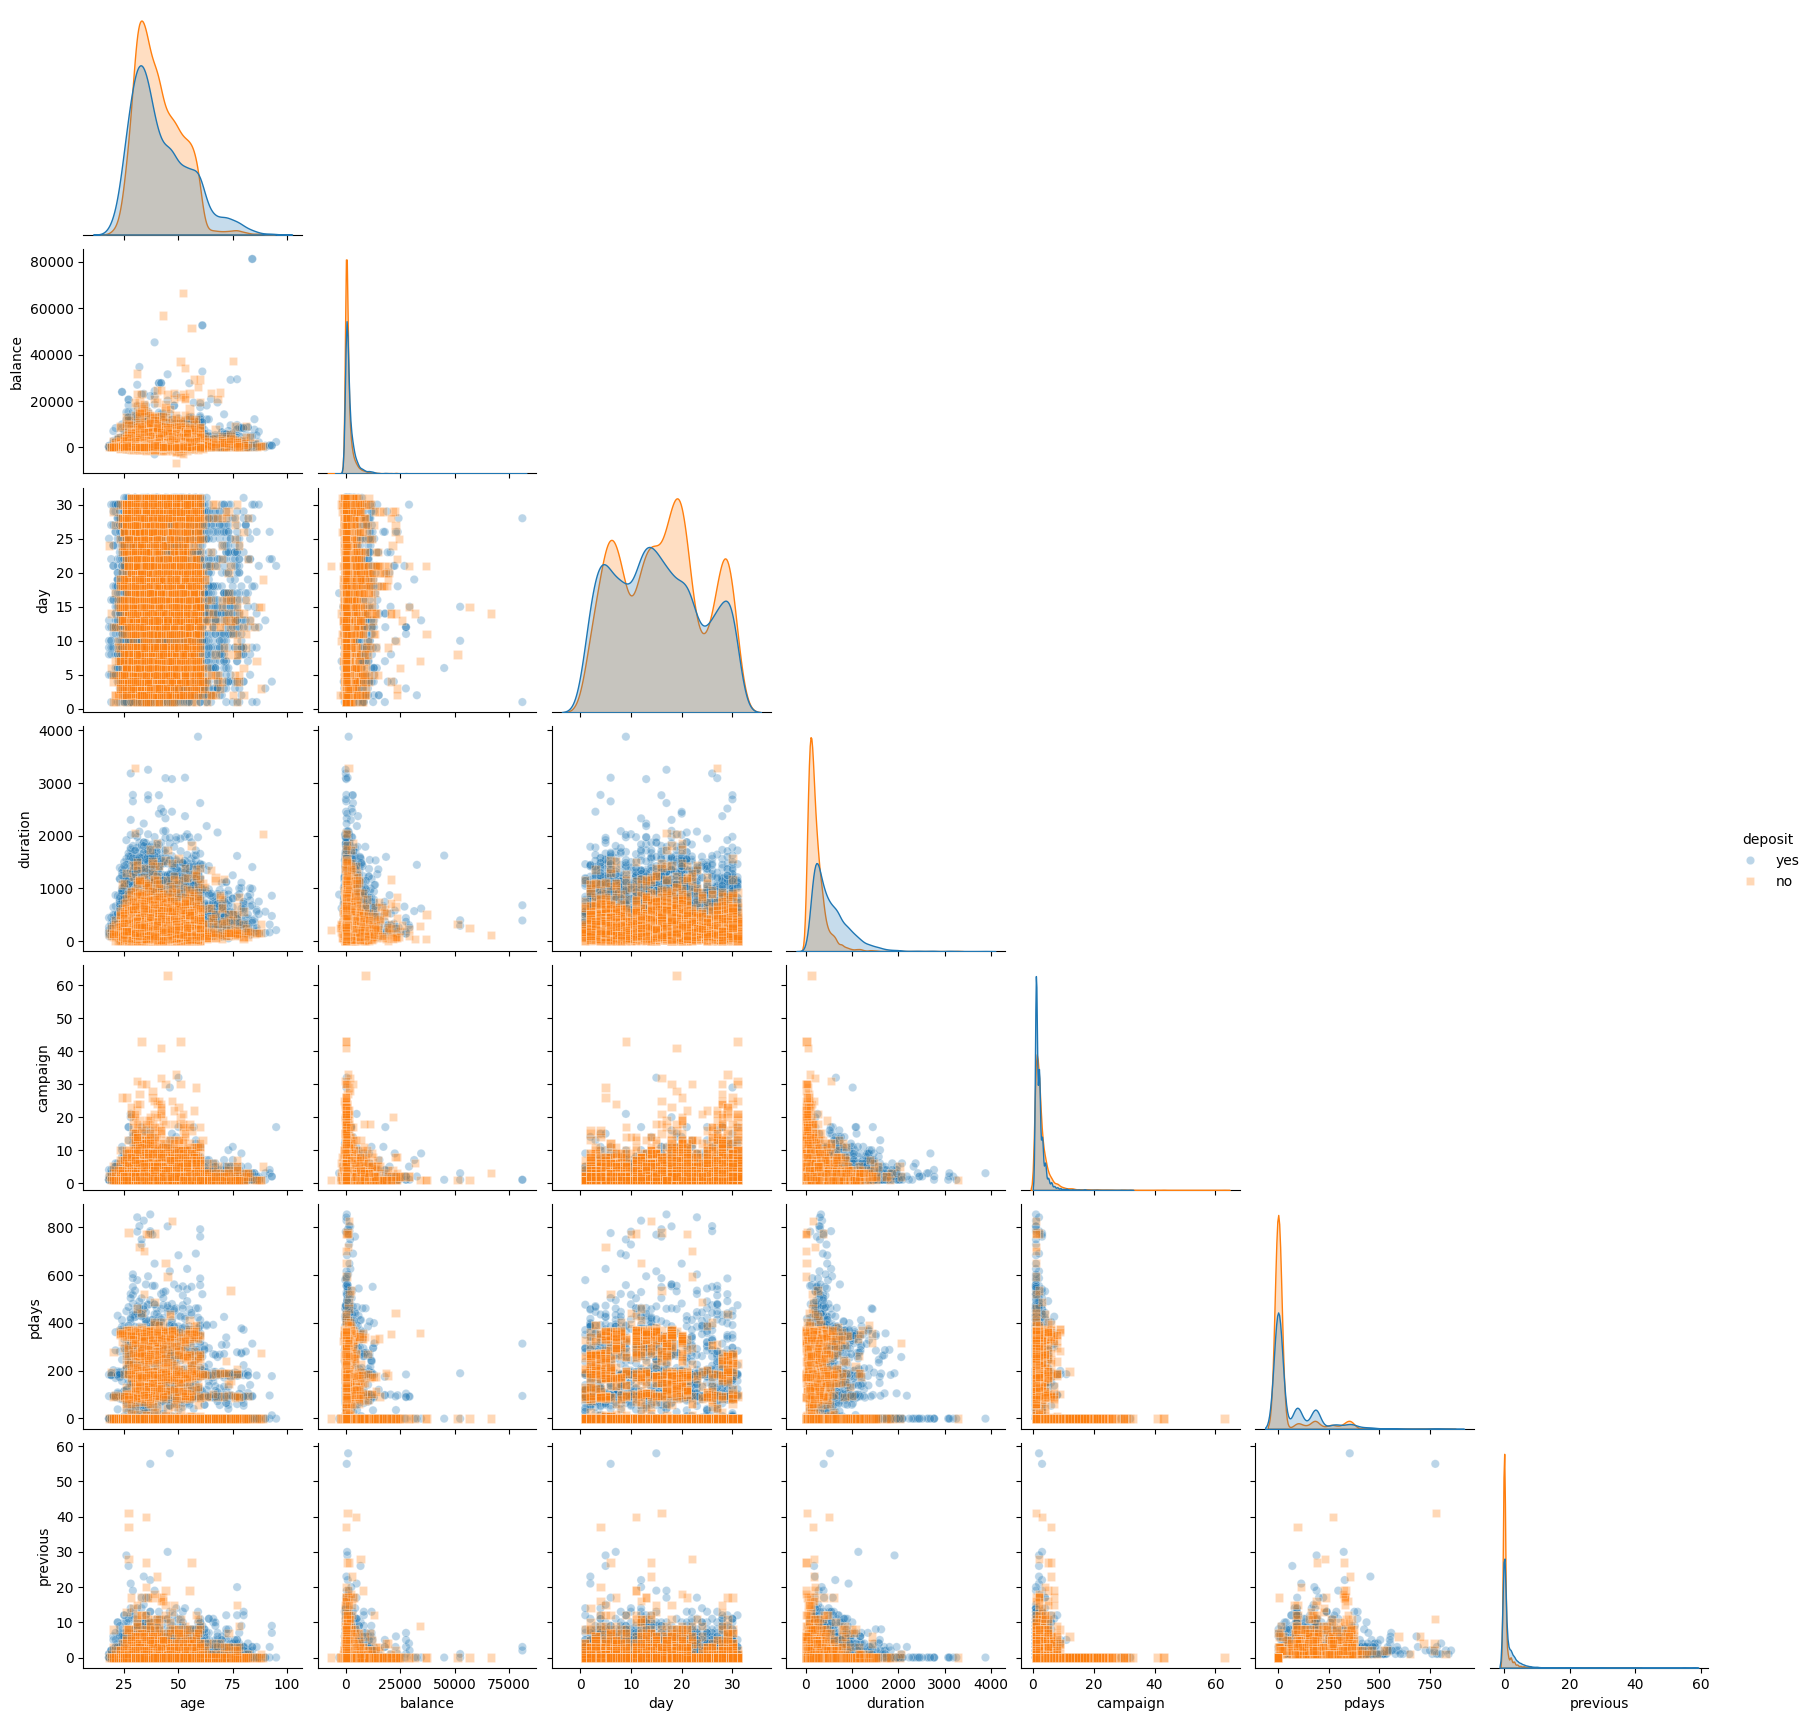

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df, hue="deposit", markers=["o", "s"], plot_kws={"alpha": 0.3}, corner=True)
plt.show()

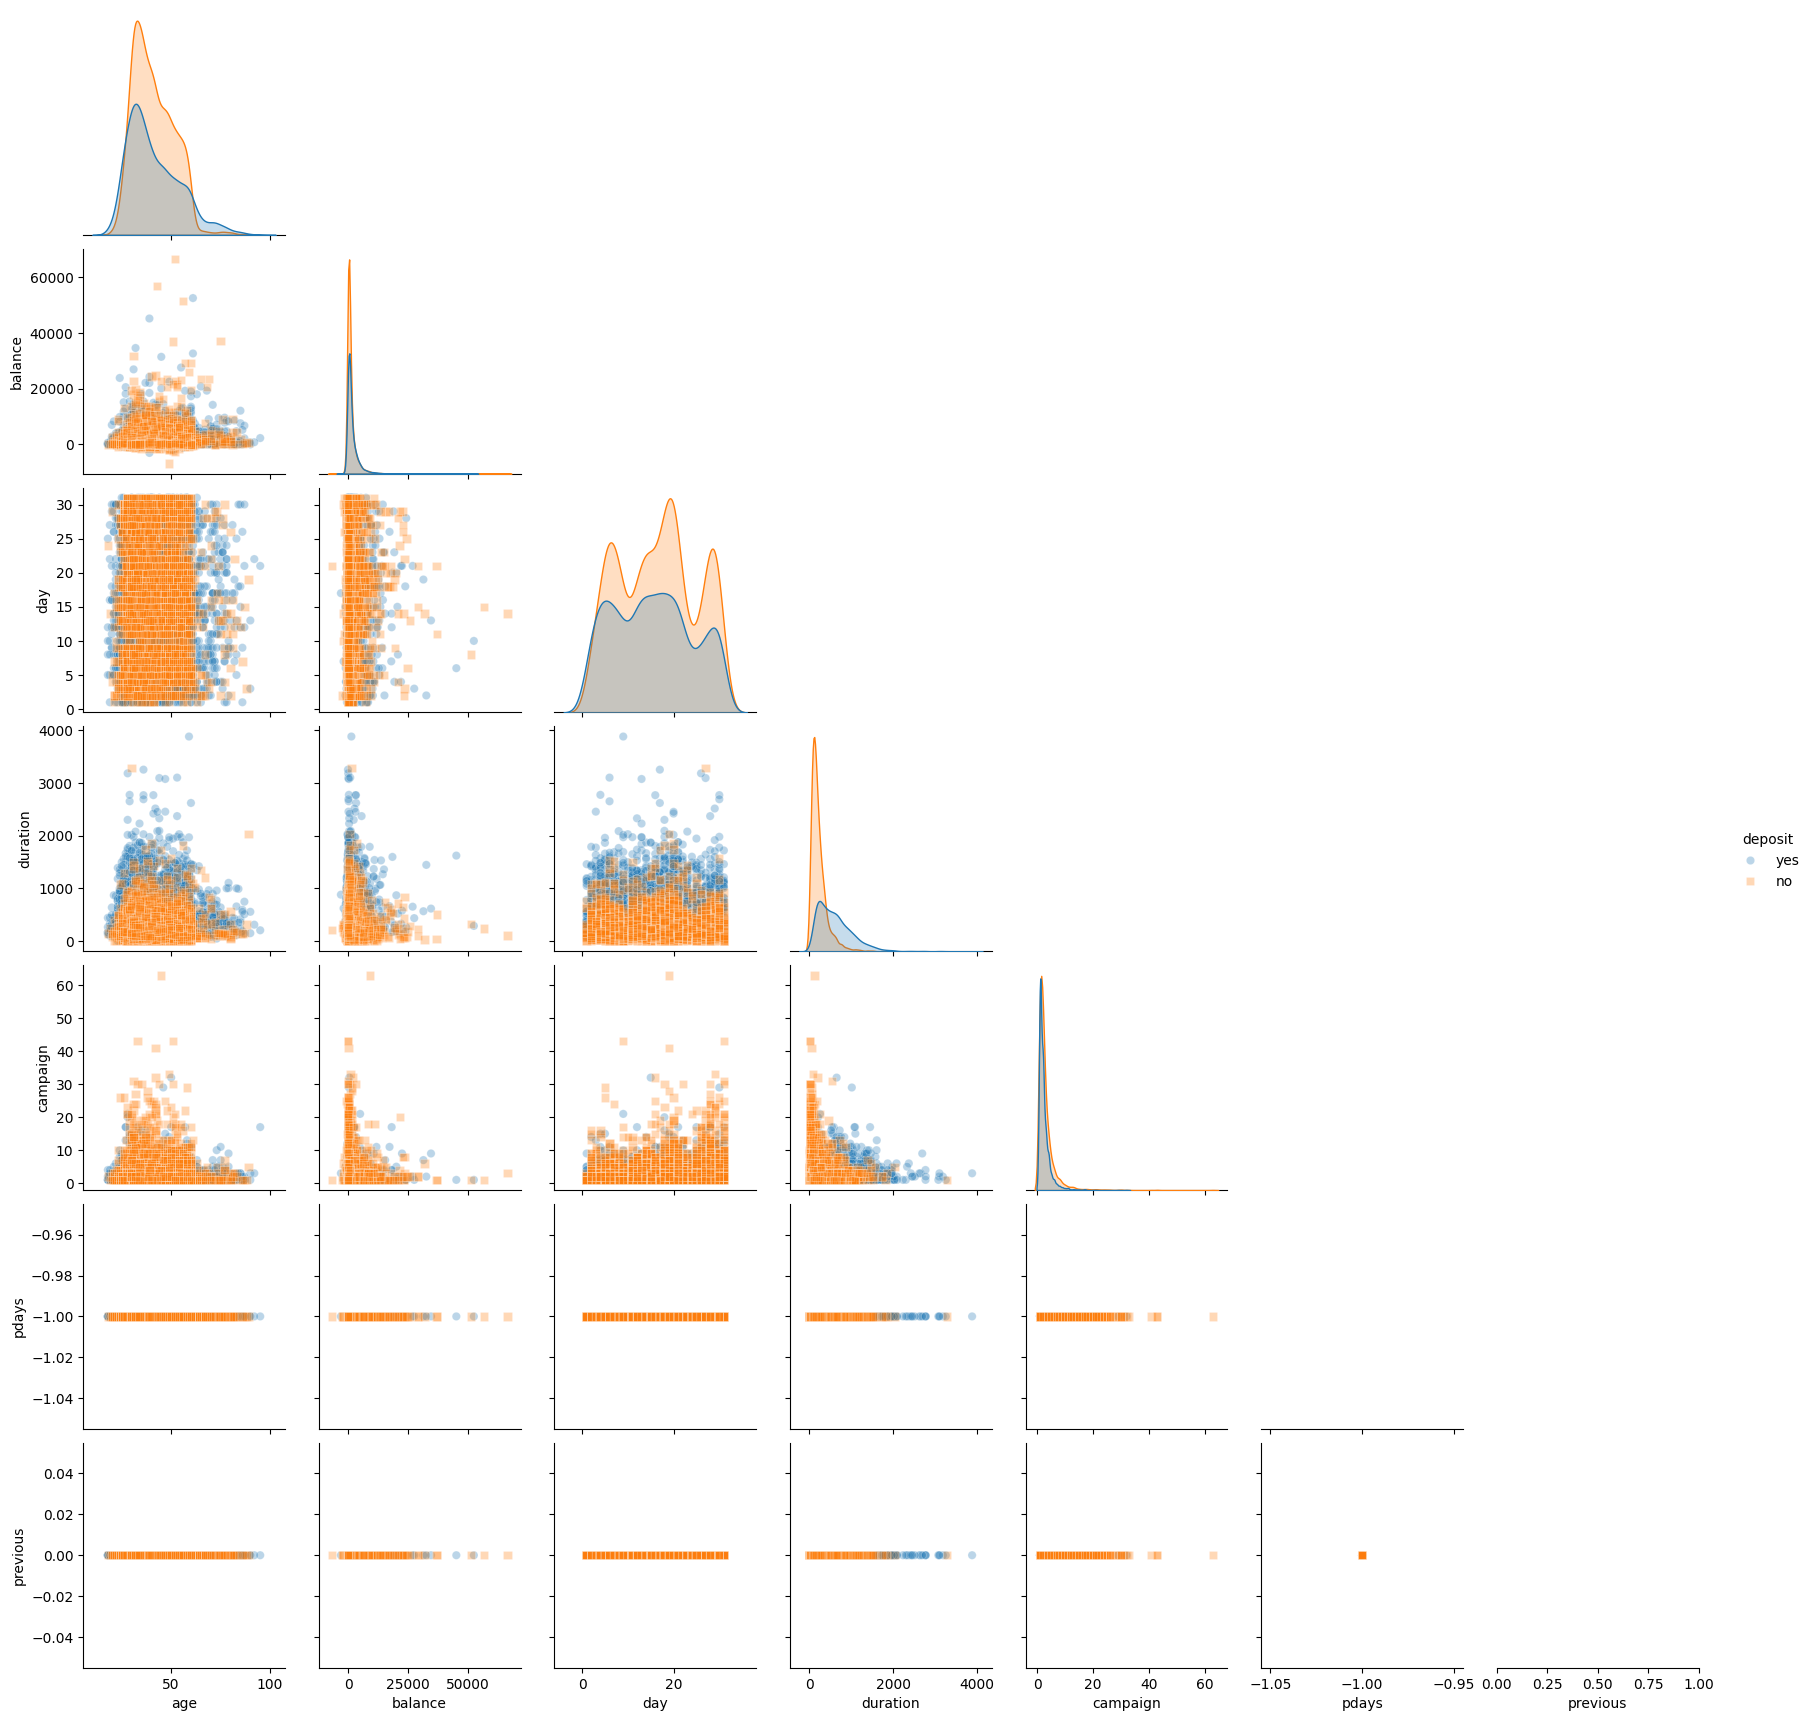

In [11]:
not_previous_contact = df[df['pdays'] == -1]
sns.pairplot(not_previous_contact, hue="deposit", markers=["o", "s"], plot_kws={"alpha": 0.3}, corner=True)
plt.show()

<Axes: >

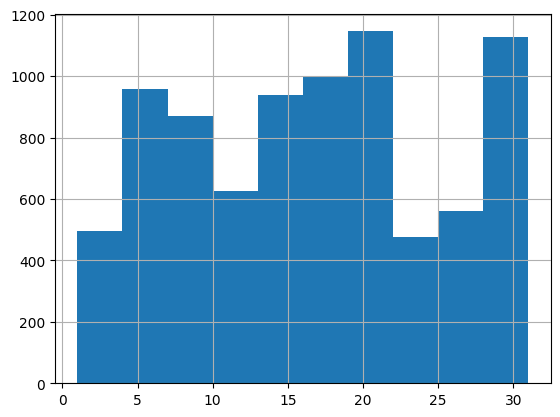

In [12]:
not_previous_contact['day'].hist()

In [ ]:
def pdays_transform(x):
    if x == -1:
        return 0
    else:
        return 1


df["pdays"].map(pdays_transform)
df["wasContacted"] = df["pdays"].map(pdays_transform)

df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,Contacted
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes,0
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes,0
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes,0
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes,0
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no,0
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no,0
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no,0
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no,1


Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='contactedLabel'>

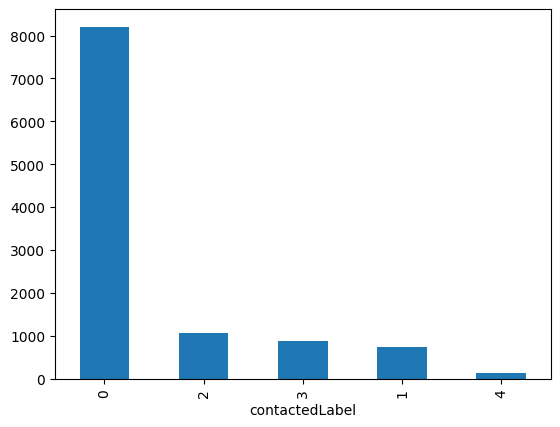

In [12]:

def bin_pdays(x):
    if x == -1:
        return 0
    if x < 100:
        return 1
    elif x < 200:
        return 2
    elif x < 400:
        return 3
    else:
        return 4

df['contactedLabel'] = df['pdays'].map(bin_pdays)
df['contactedLabel'].value_counts(sort=True).plot(kind='bar')
    
